# Practica 3 Resuelta (LICQ)

Este notebook resuelve el set de problemas de `Practica3.pdf`:

1. `f(x,y)=4x^2+y^2` con `x^2+3y^2<=16`, `y>=-2`.
2. `f(x,y)=x` con `x>=0`, `y>=1`, `y=x^2`.
3. `f(x,y)=y` con `x^2+y^2<=4`, `4x^2+y^2>=4`.

En cada ejercicio: conjunto factible, analisis LICQ, minimo/maximo y grafica en computadora.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## Ejercicio 1
Problema:

- Objetivo: `f(x,y)=4x^2+y^2`
- Restricciones: `g1(x,y)=x^2+3y^2-16<=0`, `g2(x,y)=-y-2<=0` (equivale a `y>=-2`).

Analisis LICQ:

- `grad g1=(2x,6y)`, `grad g2=(0,-1)`.
- Si ambas activas: `y=-2` y `x=+-2`, entonces `grad g1=(+-4,-12)` y `grad g2=(0,-1)`, linealmente independientes.
- No hay puntos activos donde LICQ falle.

Extremos restringidos:

- Minimo global: `(0,0)`, valor `f=0`.
- Maximo global: `(4,0)` y `(-4,0)`, valor `f=64`.

Aprox minimo numerico: (np.float64(-0.0060085836909866686), np.float64(-0.004577968526466414)) f= 0.000165370107715681
Aprox maximo numerico: (np.float64(-3.995708154506438), np.float64(-0.10529327610872663)) f= 63.873821297950684


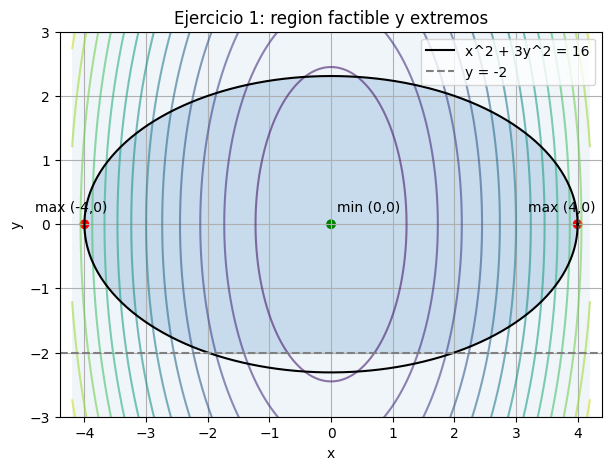

In [2]:
# Verificacion numerica por malla
x = np.linspace(-4.2, 4.2, 700)
y = np.linspace(-3.2, 3.2, 700)
X, Y = np.meshgrid(x, y)
feasible = (X**2 + 3*Y**2 <= 16) & (Y >= -2)
F = 4*X**2 + Y**2

F_min = np.where(feasible, F, np.inf)
F_max = np.where(feasible, F, -np.inf)
imin = np.unravel_index(np.argmin(F_min), F_min.shape)
imax = np.unravel_index(np.argmax(F_max), F_max.shape)

print('Aprox minimo numerico:', (X[imin], Y[imin]), 'f=', F_min[imin])
print('Aprox maximo numerico:', (X[imax], Y[imax]), 'f=', F_max[imax])

# Fronteras
theta = np.linspace(0, 2*np.pi, 500)
xe = 4*np.cos(theta)
ye = (4/np.sqrt(3))*np.sin(theta)

plt.contourf(X, Y, feasible.astype(int), levels=[-0.5, 0.5, 1.5], alpha=0.25, cmap='Blues')
plt.contour(X, Y, F, levels=15, alpha=0.6)
plt.plot(xe, ye, 'k', label='x^2 + 3y^2 = 16')
plt.axhline(-2, color='gray', linestyle='--', label='y = -2')
plt.scatter([0, 4, -4], [0, 0, 0], c=['green', 'red', 'red'])
plt.text(0.1, 0.2, 'min (0,0)')
plt.text(3.2, 0.2, 'max (4,0)')
plt.text(-4.8, 0.2, 'max (-4,0)')
plt.xlim(-4.4, 4.4)
plt.ylim(-3.0, 3.0)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ejercicio 1: region factible y extremos')
plt.legend()
plt.show()

## Ejercicio 2
Problema:

- Objetivo: `f(x,y)=x`
- Restricciones: `g1(x,y)=-x<=0` (`x>=0`), `g2(x,y)=1-y<=0` (`y>=1`) y `h(x,y)=y-x^2=0`.

Conjunto factible:

- De `y=x^2` y `y>=1` se obtiene `x^2>=1`.
- Junto con `x>=0`, resulta `x>=1` y `y=x^2`.

Analisis LICQ:

- `grad h=(-2x,1)` siempre no nulo para `x>=1`.
- En `x>1` solo esta activa la igualdad, LICQ se cumple.
- En `(1,1)` tambien esta activa `g2`; `grad g2=(0,-1)` y `grad h=(-2,1)` son independientes.
- No hay falla de LICQ en puntos factibles.

Extremos:

- Minimo restringido: `(1,1)`, valor `f=1`.
- No existe maximo restringido (problema no acotado superiormente).

Minimo restringido en (1,1), f=1
Maximo restringido: no existe (f=x -> +infinito cuando x -> +infinito)


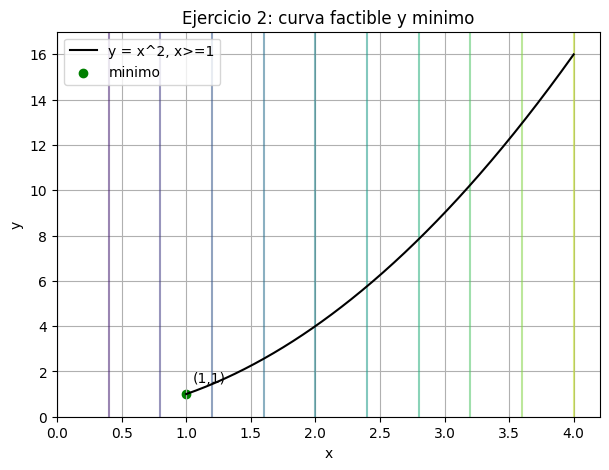

In [3]:
x = np.linspace(1, 4, 400)
y = x**2
f = x

print('Minimo restringido en (1,1), f=1')
print('Maximo restringido: no existe (f=x -> +infinito cuando x -> +infinito)')

xg = np.linspace(0, 4.2, 500)
yg = np.linspace(0, 17, 500)
X, Y = np.meshgrid(xg, yg)
F = X

plt.contour(X, Y, F, levels=12, alpha=0.55)
plt.plot(x, y, 'k', label='y = x^2, x>=1')
plt.scatter([1], [1], c='green', label='minimo')
plt.text(1.05, 1.5, '(1,1)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ejercicio 2: curva factible y minimo')
plt.legend()
plt.xlim(0, 4.2)
plt.ylim(0, 17)
plt.show()

## Ejercicio 3
Problema:

- Objetivo: `f(x,y)=y`
- Restricciones: `g1(x,y)=x^2+y^2-4<=0` y `g2(x,y)=4-4x^2-y^2<=0` (equivale a `4x^2+y^2>=4`).

Analisis LICQ:

- `grad g1=(2x,2y)`, `grad g2=(-8x,-2y)`.
- Cuando ambas activas: resolver
  `x^2+y^2=4` y `4x^2+y^2=4` da `x=0`, `y=+-2`.
- En `(0,2)` y `(0,-2)`: `grad g1=(0,+-4)` y `grad g2=(0,-+4)` son dependientes.
- LICQ falla exactamente en esos dos puntos activos.

Extremos restringidos:

- Maximo restringido: `(0,2)`, valor `f=2`.
- Minimo restringido: `(0,-2)`, valor `f=-2`.

Aprox minimo numerico: (np.float64(-0.07238912732474967), np.float64(-1.9985693848354793)) f= -1.9985693848354793
Aprox maximo numerico: (np.float64(-0.07238912732474967), np.float64(1.9985693848354797)) f= 1.9985693848354797
Puntos exactos: minimo (0,-2), maximo (0,2)
LICQ falla en (0,-2) y (0,2) porque ambos gradientes activos son colineales.


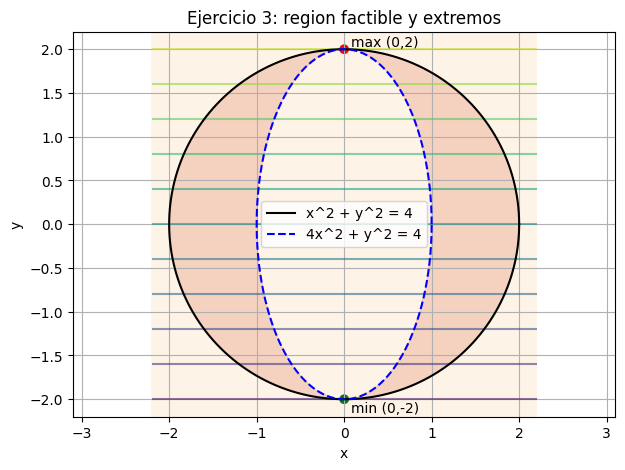

In [4]:
x = np.linspace(-2.2, 2.2, 700)
y = np.linspace(-2.2, 2.2, 700)
X, Y = np.meshgrid(x, y)
feasible = (X**2 + Y**2 <= 4) & (4*X**2 + Y**2 >= 4)
F = Y

F_min = np.where(feasible, F, np.inf)
F_max = np.where(feasible, F, -np.inf)
imin = np.unravel_index(np.argmin(F_min), F_min.shape)
imax = np.unravel_index(np.argmax(F_max), F_max.shape)

print('Aprox minimo numerico:', (X[imin], Y[imin]), 'f=', F_min[imin])
print('Aprox maximo numerico:', (X[imax], Y[imax]), 'f=', F_max[imax])
print('Puntos exactos: minimo (0,-2), maximo (0,2)')
print('LICQ falla en (0,-2) y (0,2) porque ambos gradientes activos son colineales.')

t = np.linspace(0, 2*np.pi, 600)
xc = 2*np.cos(t)
yc = 2*np.sin(t)
xe = np.cos(t)
ye = 2*np.sin(t)

plt.contourf(X, Y, feasible.astype(int), levels=[-0.5, 0.5, 1.5], alpha=0.25, cmap='Oranges')
plt.contour(X, Y, F, levels=12, alpha=0.6)
plt.plot(xc, yc, 'k', label='x^2 + y^2 = 4')
plt.plot(xe, ye, 'b--', label='4x^2 + y^2 = 4')
plt.scatter([0, 0], [2, -2], c=['red', 'green'])
plt.text(0.08, 2.03, 'max (0,2)')
plt.text(0.08, -2.15, 'min (0,-2)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ejercicio 3: region factible y extremos')
plt.axis('equal')
plt.legend()
plt.show()

## Resumen Final

- Ejercicio 1: LICQ no falla; minimo `(0,0)` y maximos `(+-4,0)`.
- Ejercicio 2: LICQ no falla; minimo `(1,1)` y no hay maximo.
- Ejercicio 3: LICQ falla en `(0,2)` y `(0,-2)`; maximo `(0,2)` y minimo `(0,-2)`.